In [1]:
from pathlib import Path
import sys

# Works whether Jupyter's cwd is the repo root or analysis/
src = next(
    (p / "analysis" / "src")
    for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / "analysis" / "src" / "util.py").is_file()
)
sys.path.insert(0, str(src))

import pandas as pd
from util import load_config, save_results

ROOT, config = load_config()
dataset_one = pd.read_csv(ROOT / config["paths"]["dataset_one"])


In [2]:
# T-test: treated vs control outcomes

from scipy.stats import ttest_ind

treated = dataset_one.loc[dataset_one["treatment"] == 1, "outcome"]
control = dataset_one.loc[dataset_one["treatment"] == 0, "outcome"]

ttest = ttest_ind(treated, control)

results = save_results(
    "ttest_ind",
    {
        "statistic": float(ttest.statistic),
        "pvalue": float(ttest.pvalue),
        "df": float(ttest.df),
    },
    ROOT,
    config,
)

results


{'ttest_ind': {'statistic': 7.078412766399069,
  'pvalue': 2.7456476351697987e-12,
  'df': 998.0},
 'treatment_effect': {'beta': 0.440431917318543,
  'ci_low': 0.3249609325601786,
  'ci_high': 0.5609720327665985},
 'ttest_ind_r': {'statistic': -7.0784, 'pvalue': 2.7456e-12, 'df': 998},
 'treatment_effect_r': {'beta': 0.4401, 'ci_low': 0.3273, 'ci_high': 0.5585}}

In [3]:
# Bayesian model of the treatment effect + ArviZ plots

import arviz as az
import matplotlib.pyplot as plt
import pymc as pm

treatment = dataset_one["treatment"].to_numpy()
outcome = dataset_one["outcome"].to_numpy()

with pm.Model() as model:
    outcome_obs = pm.Data("outcome_obs", outcome)
    alpha = pm.Normal("alpha", mu=0, sigma=10, shape=2) 
    sigma = pm.HalfNormal("sigma", sigma=10)
    pm.Normal("obs", mu=alpha[treatment], sigma=sigma, observed=outcome)


with model:
    idata = pm.sample(
        draws=config["python"]["draws"],
        tune=config["python"]["tune"],
        random_seed=config["seed"],
        progressbar=False,
        )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


In [4]:
summary = az.summary(idata, var_names=["alpha", "sigma"])
summary

table_path = ROOT / config["paths"]["tables"] / "pymc_alpha_sigma.tex"
table_path.write_text(summary.to_latex())
summary


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha[0],4.029,0.0445,4,4.1,5906,3302,1.00,0.00058,0.00042
alpha[1],4.47,0.0428,4.4,4.5,6409,3392,1.00,0.00054,0.00038
sigma,0.9859,0.0223,0.95,1,5919,2799,1.00,0.00029,0.00022


In [5]:
# Calculate treatment effect (treated - control)
idata.posterior["beta"] = (
    idata.posterior["alpha"].isel(alpha_dim_0=1)
    - idata.posterior["alpha"].isel(alpha_dim_0=0)
)
beta = idata.posterior["beta"]
az.summary(idata, var_names=["beta"])

treatment_effect = {
    "beta": float(beta.mean()),
    "ci_low": float(beta.quantile(0.03)),
    "ci_high": float(beta.quantile(0.97)),
}

save_results("treatment_effect", treatment_effect, ROOT, config)


{'ttest_ind': {'statistic': 7.078412766399069,
  'pvalue': 2.7456476351697987e-12,
  'df': 998.0},
 'treatment_effect': {'beta': 0.440431917318543,
  'ci_low': 0.3249609325601786,
  'ci_high': 0.5609720327665985},
 'ttest_ind_r': {'statistic': -7.0784, 'pvalue': 2.7456e-12, 'df': 998},
 'treatment_effect_r': {'beta': 0.4401, 'ci_low': 0.3273, 'ci_high': 0.5585}}

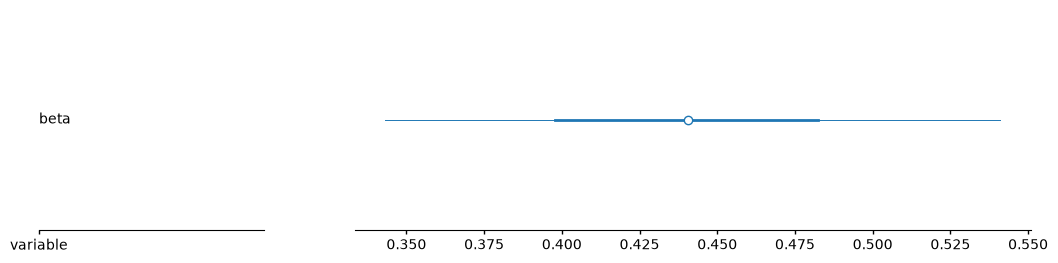

In [6]:
# Plot the treatment effect
# plot_forest needs InferenceData/DataTree with a posterior group — not a bare DataArray
az.plot_forest(idata, var_names=["beta"], combined=True)
plt.savefig(
    ROOT / config["paths"]["figures"] / "trace_treatment_effect.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
